# Fitness Data Analysis

---

## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Style ──────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})
BRAND = '#FC4C02'   # Strava/activity orange
SLEEP = '#4C72B0'   # calm blue for sleep

## 2. Load Data

In [2]:
daily     = pd.read_csv('dailyActivity_cleaned.csv')
hourly_c  = pd.read_csv('hourlyCalories_cleaned.csv')
hourly_i  = pd.read_csv('hourlyIntensities_cleaned.csv')
heartrate = pd.read_csv('heartrate_seconds_merged.csv')

print(f"Daily activity rows : {len(daily):,}")
print(f"Hourly calories rows: {len(hourly_c):,}")
print(f"Hourly intensity rows:{len(hourly_i):,}")
print(f"Heart-rate rows     : {len(heartrate):,}")

Daily activity rows : 936
Hourly calories rows: 22,099
Hourly intensity rows:22,099
Heart-rate rows     : 2,483,658


## 3. Data Cleaning

In [3]:
# ── Parse dates ────────────────────────────────────────────────────────────
daily['ActivityDate'] = pd.to_datetime(daily['ActivityDate'])
hourly_c['ActivityHour'] = pd.to_datetime(hourly_c['ActivityHour'])
hourly_i['ActivityHour'] = pd.to_datetime(hourly_i['ActivityHour'])
heartrate['Time'] = pd.to_datetime(heartrate['Time'])

# ── Add useful time columns (only if not already present) ──────────────────
if 'DayOfWeek' not in daily.columns:
    daily['DayOfWeek'] = daily['ActivityDate'].dt.day_name()
if 'WeekNumber' not in daily.columns:
    daily['WeekNumber'] = daily['ActivityDate'].dt.isocalendar().week.astype(int)

hourly_c['Hour'] = hourly_c['ActivityHour'].dt.hour
hourly_i['Hour'] = hourly_i['ActivityHour'].dt.hour

heartrate['Hour'] = heartrate['Time'].dt.hour
heartrate['Date'] = heartrate['Time'].dt.date

# ── Drop zero-step days (device not worn) ──────────────────────────────────
daily_clean = daily[daily['TotalSteps'] > 0].copy()

# ── Check nulls ────────────────────────────────────────────────────────────
print("Null counts – daily activity:")
print(daily_clean.isnull().sum())
print(f"\nUnique users: {daily_clean['Id'].nunique()}")
print(f"Date range  : {daily_clean['ActivityDate'].min().date()} → {daily_clean['ActivityDate'].max().date()}")

Null counts – daily activity:
Id                          0
ActivityDate                0
TotalSteps                  0
TotalDistance               0
TrackerDistance             0
LoggedActivitiesDistance    0
VeryActiveDistance          0
ModeratelyActiveDistance    0
LightActiveDistance         0
SedentaryActiveDistance     0
VeryActiveMinutes           0
FairlyActiveMinutes         0
LightlyActiveMinutes        0
SedentaryMinutes            0
Calories                    0
DayOfWeek                   0
DayNumber                   0
Month                       0
WeekNumber                  0
dtype: int64

Unique users: 33
Date range  : 2016-04-12 → 2016-05-12


In [4]:
daily_clean.describe().round(2)

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,DayNumber,WeekNumber
count,8.630000e+02,863,863.00,863.00,863.00,863.00,863.00,863.00,863.00,863.00,863.00,863.00,863.00,863.00,863.00,863.00,863.00
mean,4.857542e+09,2016-04-26 02:16:49.501738240,8319.39,5.98,5.96,0.12,1.64,0.62,3.64,0.00,23.02,14.78,210.02,955.75,2361.30,2.92,16.74
min,1.503960e+09,2016-04-12 00:00:00,4.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,52.00,0.00,15.00
25%,2.320127e+09,2016-04-18 00:00:00,4923.00,3.37,3.37,0.00,0.00,0.00,2.34,0.00,0.00,0.00,146.50,721.50,1855.50,1.00,16.00
50%,4.445115e+09,2016-04-26 00:00:00,8053.00,5.59,5.59,0.00,0.41,0.31,3.58,0.00,7.00,8.00,208.00,1021.00,2220.00,3.00,17.00
75%,6.962181e+09,2016-05-03 00:00:00,11092.50,7.90,7.88,0.00,2.27,0.87,4.89,0.00,35.00,21.00,272.00,1189.00,2832.00,5.00,18.00
max,8.877689e+09,2016-05-12 00:00:00,36019.00,28.03,28.03,4.94,21.92,6.48,10.71,0.11,210.00,143.00,518.00,1440.00,4900.00,6.00,19.00
std,2.418405e+09,NaN,4744.97,3.72,3.70,0.65,2.74,0.91,1.86,0.01,33.65,20.43,96.78,280.29,702.71,1.94,1.28


## 4. User Classification by Activity Level

Using the CDC recommended 10,000 steps/day benchmark:
- **Sedentary** < 5,000 steps  
- **Lightly Active** 5,000–7,499  
- **Fairly Active** 7,500–9,999  
- **Very Active** ≥ 10,000

In [5]:
user_avg = daily_clean.groupby('Id').agg(
    Avg_Steps      = ('TotalSteps',       'mean'),
    Avg_Calories   = ('Calories',         'mean'),
    Avg_Sedentary  = ('SedentaryMinutes', 'mean'),
    Avg_VeryActive = ('VeryActiveMinutes','mean'),
    Avg_Distance   = ('TotalDistance',    'mean'),
    Days_Tracked   = ('ActivityDate',     'count'),
).reset_index()

def classify(steps):
    if steps < 5000:   return 'Sedentary'
    if steps < 7500:   return 'Lightly Active'
    if steps < 10000:  return 'Fairly Active'
    return 'Very Active'

user_avg['ActivityLevel'] = user_avg['Avg_Steps'].apply(classify)

level_order  = ['Sedentary', 'Lightly Active', 'Fairly Active', 'Very Active']
level_colors = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4']

counts = user_avg['ActivityLevel'].value_counts().reindex(level_order).fillna(0)
print(counts)

ActivityLevel
Sedentary          7
Lightly Active     9
Fairly Active     10
Very Active        7
Name: count, dtype: int64


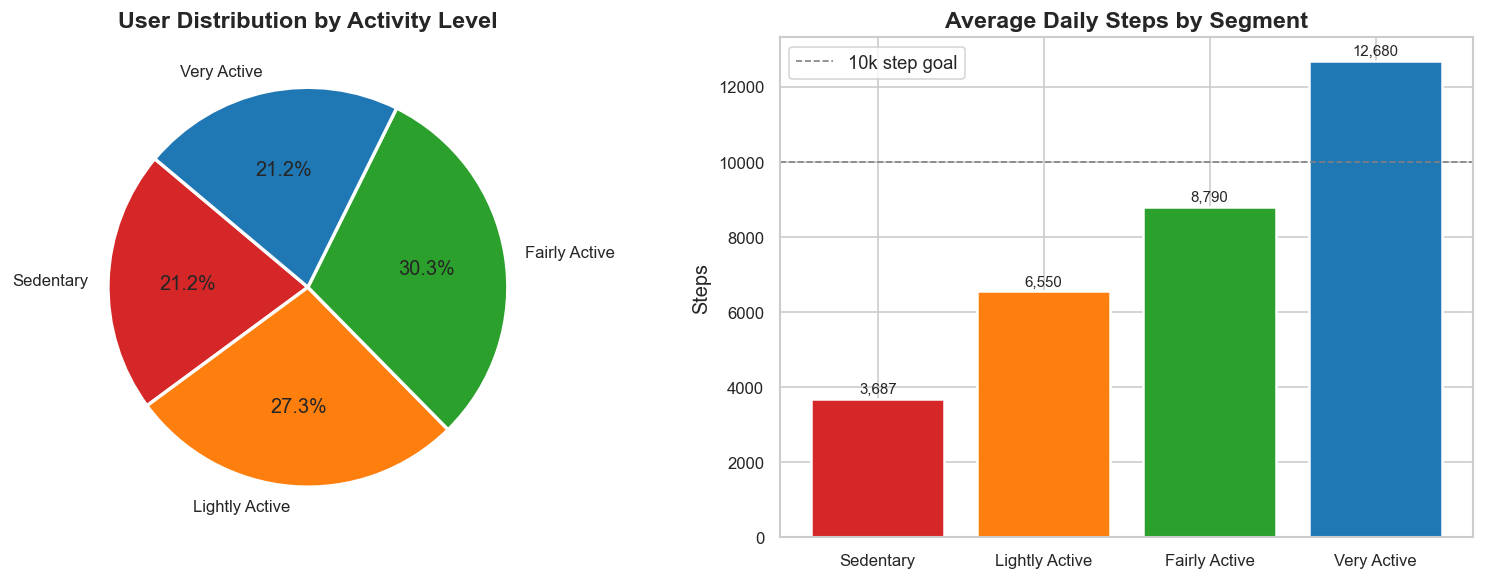

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Pie chart
axes[0].pie(counts, labels=counts.index, colors=level_colors,
            autopct='%1.1f%%', startangle=140,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0].set_title('User Distribution by Activity Level')

# Bar – avg steps per segment
seg_steps = user_avg.groupby('ActivityLevel')['Avg_Steps'].mean().reindex(level_order)
bars = axes[1].bar(seg_steps.index, seg_steps.values, color=level_colors, edgecolor='white', linewidth=1.5)
axes[1].axhline(10000, color='grey', linestyle='--', linewidth=1, label='10k step goal')
axes[1].set_title('Average Daily Steps by Segment')
axes[1].set_ylabel('Steps')
axes[1].legend()
for bar, val in zip(bars, seg_steps.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 150,
                 f'{val:,.0f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## 5. How Users Spend Their Day

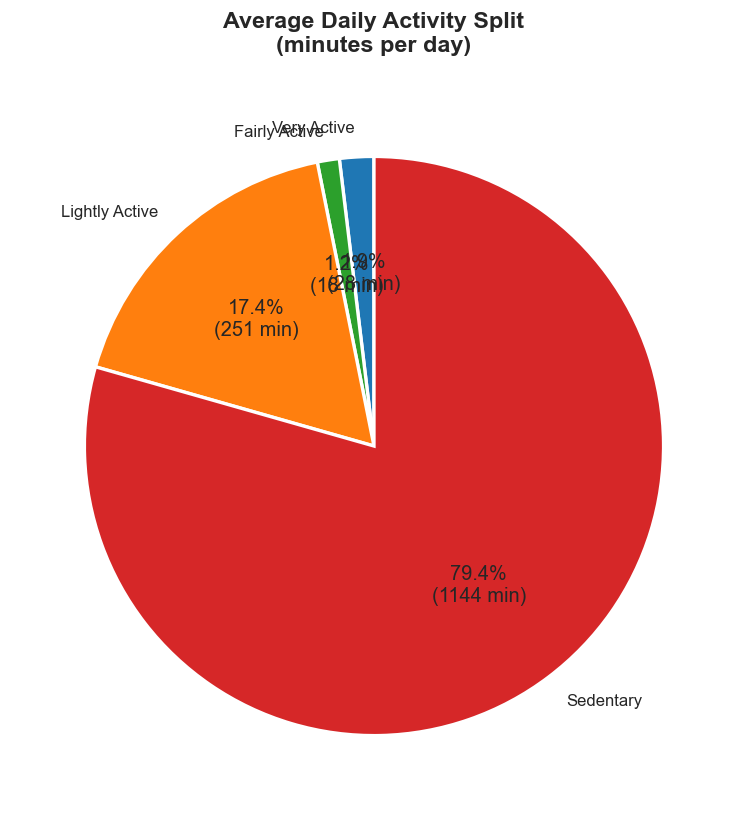

Sedentary accounts for 66.4% of the average day


In [14]:
activity_cols = ['VeryActiveMinutes', 'FairlyActiveMinutes',
                 'LightlyActiveMinutes', 'SedentaryMinutes']
labels        = ['Very Active', 'Fairly Active', 'Lightly Active', 'Sedentary']
colors        = ['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728']

avg_mins = daily_clean[activity_cols].mean()

fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    avg_mins, labels=labels, colors=colors,
    autopct=lambda p: f'{p:.1f}%\n({p*1440/100:.0f} min)',
    startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
ax.set_title('Average Daily Activity Split\n(minutes per day)', pad=20)
plt.tight_layout()
plt.show()

print(f"Sedentary accounts for {avg_mins['SedentaryMinutes']/1440*100:.1f}% of the average day")

## 6. Steps & Calories by Day of Week

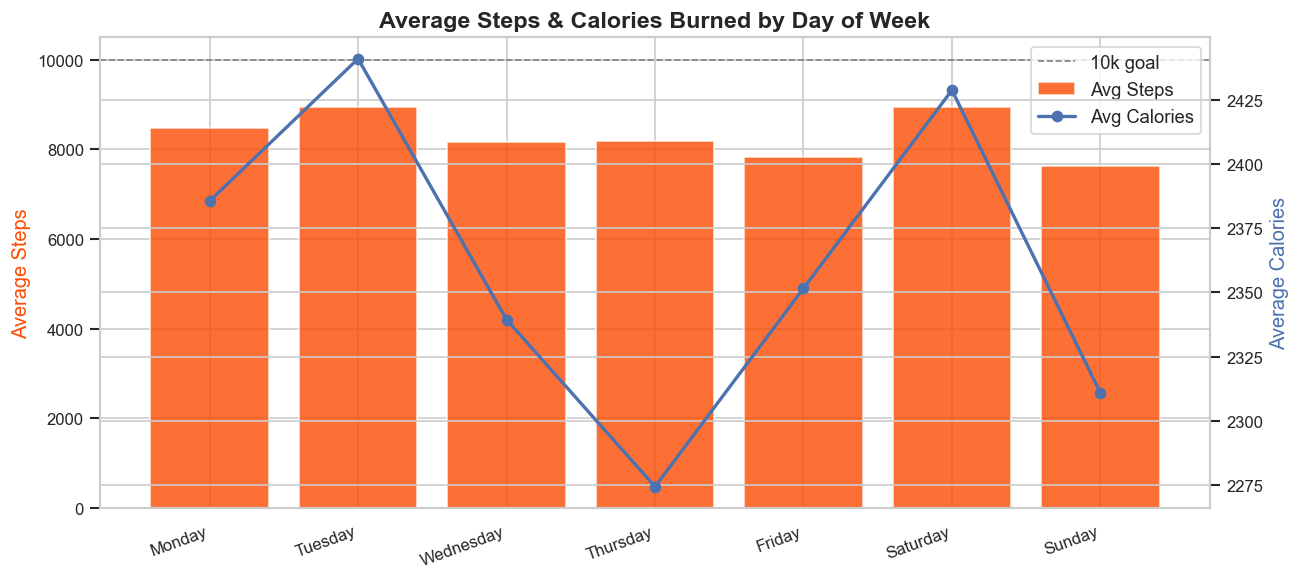

In [13]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
by_day = (daily_clean.groupby('DayOfWeek')
          .agg(Avg_Steps=('TotalSteps','mean'), Avg_Calories=('Calories','mean'))
          .reindex(day_order).reset_index())

fig, ax1 = plt.subplots(figsize=(11, 5))
x = range(len(by_day))
bars = ax1.bar(x, by_day['Avg_Steps'], color=BRAND, alpha=0.8, label='Avg Steps')
ax1.set_xticks(x)
ax1.set_xticklabels(by_day['DayOfWeek'], rotation=20, ha='right')
ax1.set_ylabel('Average Steps', color=BRAND)
ax1.axhline(10000, color='grey', linestyle='--', linewidth=1, label='10k goal')

ax2 = ax1.twinx()
ax2.plot(x, by_day['Avg_Calories'], color=SLEEP, marker='o', linewidth=2, label='Avg Calories')
ax2.set_ylabel('Average Calories', color=SLEEP)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
ax1.set_title('Average Steps & Calories Burned by Day of Week')

plt.tight_layout()
plt.show()

## 7. Hourly Activity Patterns

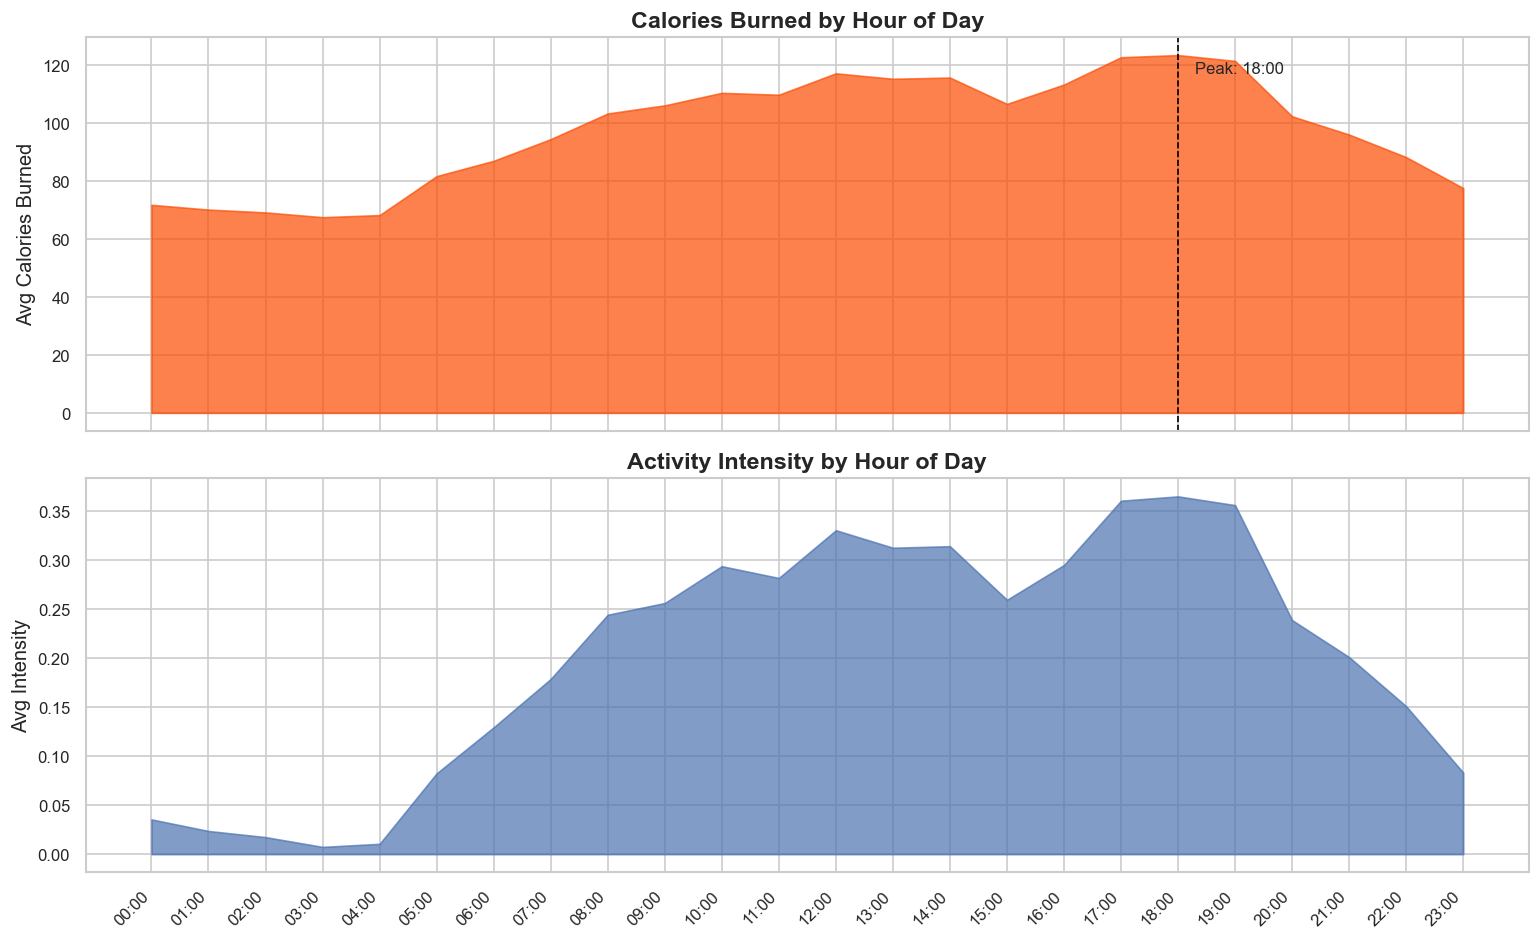

In [12]:
hourly = hourly_c.merge(hourly_i, on=['Id', 'ActivityHour'])
hourly['Hour'] = hourly['ActivityHour'].dt.hour

by_hour = hourly.groupby('Hour').agg(
    Avg_Calories  = ('Calories',          'mean'),
    Avg_Intensity = ('AverageIntensity',  'mean'),
).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

axes[0].fill_between(by_hour['Hour'], by_hour['Avg_Calories'], color=BRAND, alpha=0.7)
axes[0].set_ylabel('Avg Calories Burned')
axes[0].set_title('Calories Burned by Hour of Day')

axes[1].fill_between(by_hour['Hour'], by_hour['Avg_Intensity'], color=SLEEP, alpha=0.7)
axes[1].set_ylabel('Avg Intensity')
axes[1].set_title('Activity Intensity by Hour of Day')
axes[1].set_xticks(range(0, 24))
axes[1].set_xticklabels([f'{h:02d}:00' for h in range(24)], rotation=45, ha='right')

# Annotate peak
peak_h = by_hour.loc[by_hour['Avg_Calories'].idxmax(), 'Hour']
axes[0].axvline(peak_h, color='black', linestyle='--', linewidth=1)
axes[0].text(peak_h + 0.3, by_hour['Avg_Calories'].max() * 0.95,
             f'Peak: {peak_h}:00', fontsize=10)

plt.tight_layout()
plt.show()

## 8. Steps vs. Calories — Correlation

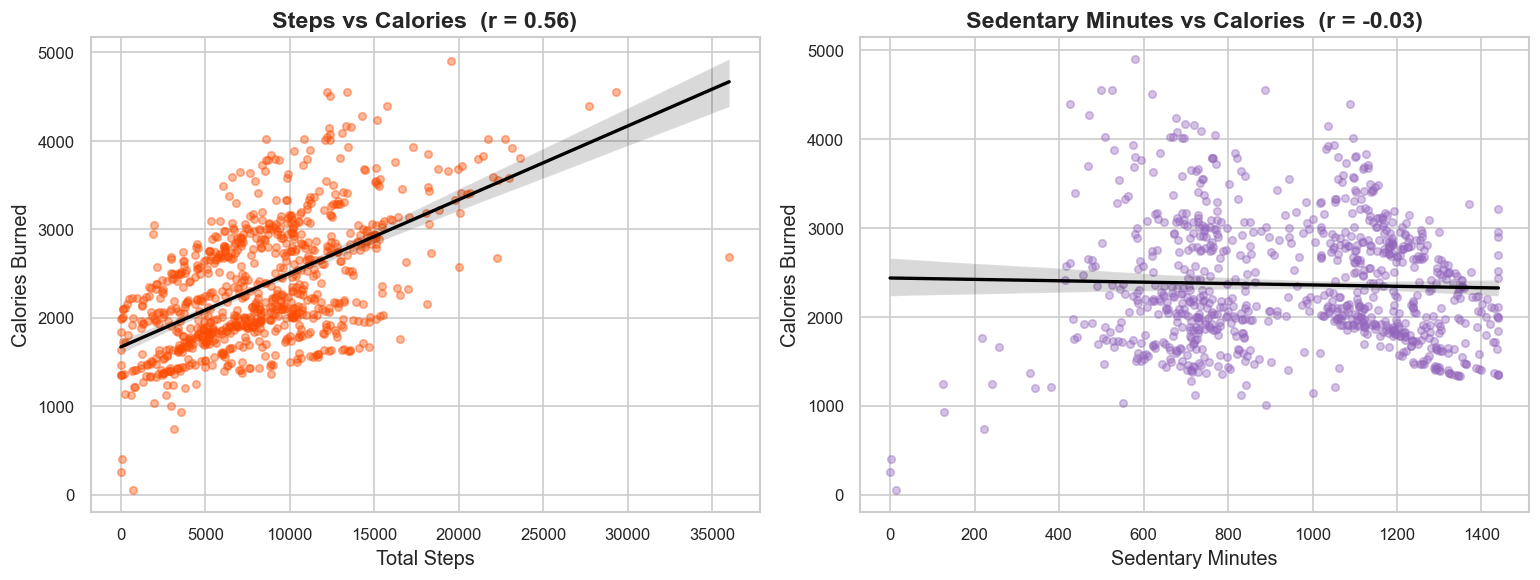

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter with regression line
sns.regplot(data=daily_clean, x='TotalSteps', y='Calories',
            scatter_kws={'alpha': 0.4, 'color': BRAND, 's': 20},
            line_kws={'color': 'black', 'linewidth': 2},
            ax=axes[0])
corr = daily_clean[['TotalSteps', 'Calories']].corr().iloc[0, 1]
axes[0].set_title(f'Steps vs Calories  (r = {corr:.2f})')
axes[0].set_xlabel('Total Steps')
axes[0].set_ylabel('Calories Burned')

# Sedentary minutes vs calories
sns.regplot(data=daily_clean, x='SedentaryMinutes', y='Calories',
            scatter_kws={'alpha': 0.4, 'color': '#9467bd', 's': 20},
            line_kws={'color': 'black', 'linewidth': 2},
            ax=axes[1])
corr2 = daily_clean[['SedentaryMinutes', 'Calories']].corr().iloc[0, 1]
axes[1].set_title(f'Sedentary Minutes vs Calories  (r = {corr2:.2f})')
axes[1].set_xlabel('Sedentary Minutes')
axes[1].set_ylabel('Calories Burned')

plt.tight_layout()
plt.show()

## 9. Heart Rate Analysis

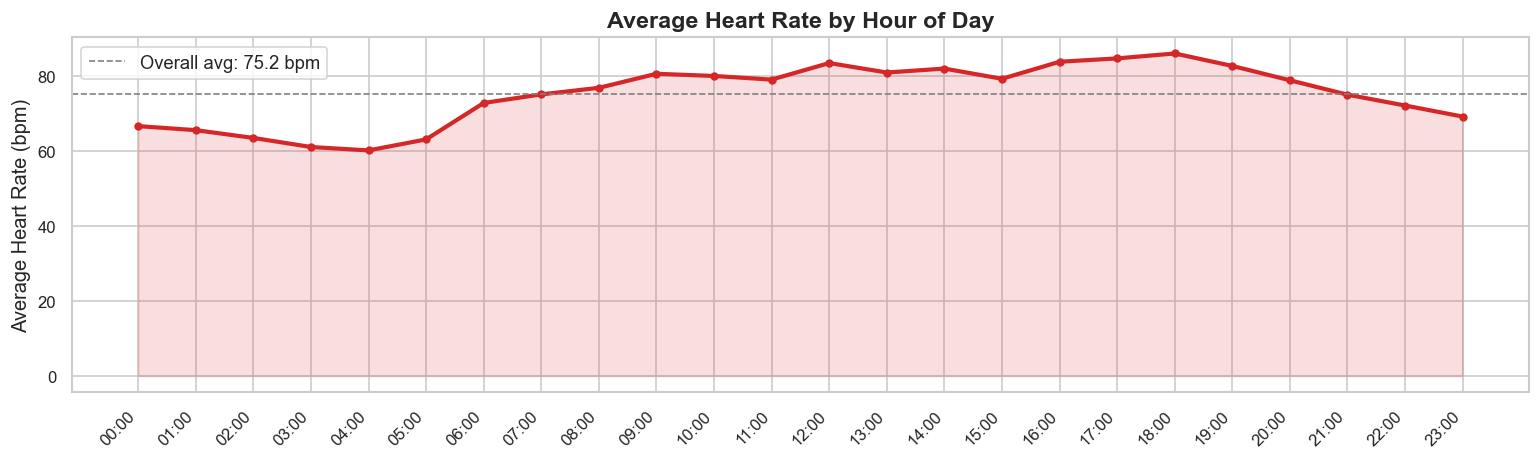

In [16]:
# Average heart rate by hour across all users
hr_hourly = heartrate.groupby('Hour')['Value'].mean().reset_index()
hr_hourly.columns = ['Hour', 'Avg_HR']

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(hr_hourly['Hour'], hr_hourly['Avg_HR'], color='#d62728', linewidth=2.5, marker='o', markersize=4)
ax.fill_between(hr_hourly['Hour'], hr_hourly['Avg_HR'], alpha=0.15, color='#d62728')
ax.axhline(hr_hourly['Avg_HR'].mean(), color='grey', linestyle='--', linewidth=1,
           label=f"Overall avg: {hr_hourly['Avg_HR'].mean():.1f} bpm")
ax.set_xticks(range(0, 24))
ax.set_xticklabels([f'{h:02d}:00' for h in range(24)], rotation=45, ha='right')
ax.set_ylabel('Average Heart Rate (bpm)')
ax.set_title('Average Heart Rate by Hour of Day')
ax.legend()
plt.tight_layout()
plt.show()

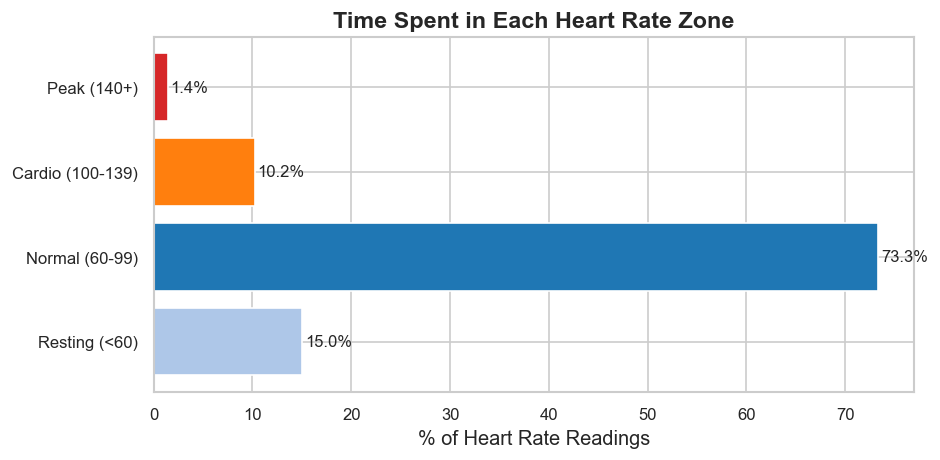

In [17]:
# Heart rate zones per user
def hr_zone(bpm):
    if bpm < 60:   return 'Resting (<60)'
    if bpm < 100:  return 'Normal (60-99)'
    if bpm < 140:  return 'Cardio (100-139)'
    return 'Peak (140+)'

heartrate['Zone'] = heartrate['Value'].apply(hr_zone)
zone_order  = ['Resting (<60)', 'Normal (60-99)', 'Cardio (100-139)', 'Peak (140+)']
zone_colors = ['#aec7e8', '#1f77b4', '#ff7f0e', '#d62728']

zone_pct = (heartrate['Zone'].value_counts(normalize=True)
            .reindex(zone_order) * 100)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(zone_pct.index, zone_pct.values, color=zone_colors, edgecolor='white')
ax.set_xlabel('% of Heart Rate Readings')
ax.set_title('Time Spent in Each Heart Rate Zone')
for bar, val in zip(bars, zone_pct.values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10)
plt.tight_layout()
plt.show()

## 10. Device Usage Consistency

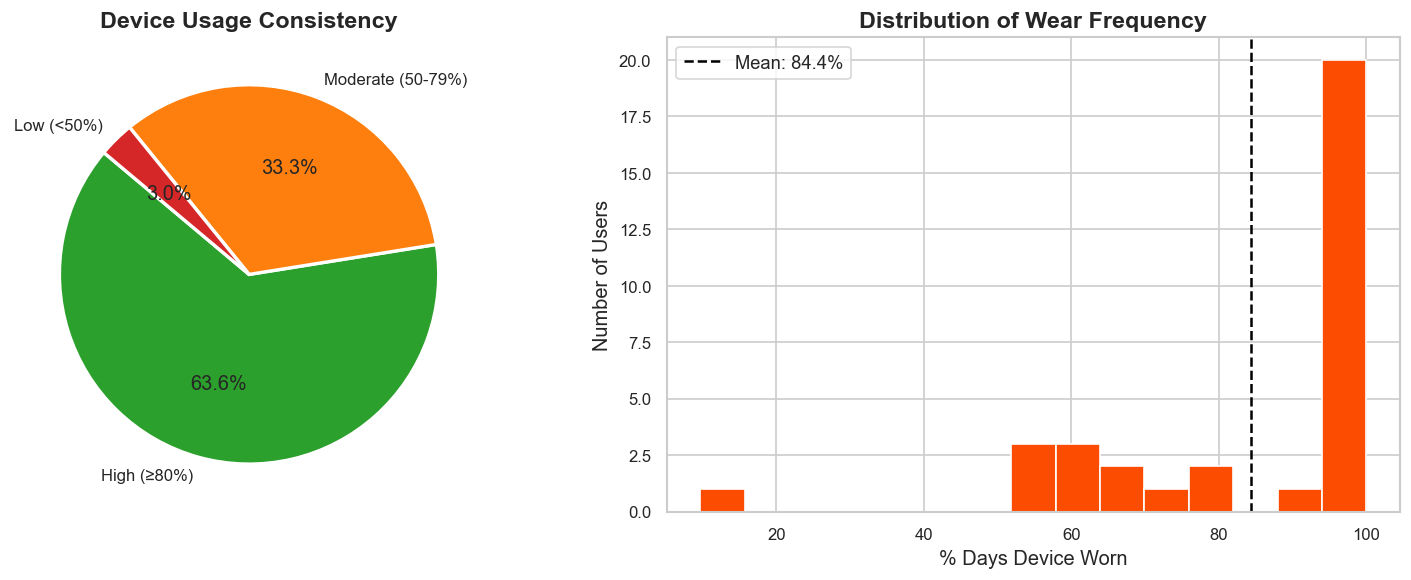

Category
High (≥80%)          21
Moderate (50-79%)    11
Low (<50%)            1
Name: count, dtype: int64


In [18]:
# How many days did each user wear the device?
usage = daily_clean.groupby('Id').size().reset_index(name='Days_Worn')
max_days = (daily_clean['ActivityDate'].max() - daily_clean['ActivityDate'].min()).days + 1

usage['Usage_Pct'] = usage['Days_Worn'] / max_days * 100

def usage_cat(pct):
    if pct >= 80: return 'High (≥80%)'
    if pct >= 50: return 'Moderate (50-79%)'
    return 'Low (<50%)'

usage['Category'] = usage['Usage_Pct'].apply(usage_cat)
cat_order  = ['High (≥80%)', 'Moderate (50-79%)', 'Low (<50%)']
cat_colors = ['#2ca02c', '#ff7f0e', '#d62728']

cat_counts = usage['Category'].value_counts().reindex(cat_order)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].pie(cat_counts, labels=cat_counts.index, colors=cat_colors,
            autopct='%1.1f%%', startangle=140,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0].set_title('Device Usage Consistency')

axes[1].hist(usage['Usage_Pct'], bins=15, color=BRAND, edgecolor='white')
axes[1].set_xlabel('% Days Device Worn')
axes[1].set_ylabel('Number of Users')
axes[1].set_title('Distribution of Wear Frequency')
axes[1].axvline(usage['Usage_Pct'].mean(), color='black', linestyle='--',
                label=f"Mean: {usage['Usage_Pct'].mean():.1f}%")
axes[1].legend()

plt.tight_layout()
plt.show()

print(usage['Category'].value_counts())

## 11. Feature Correlation Heatmap

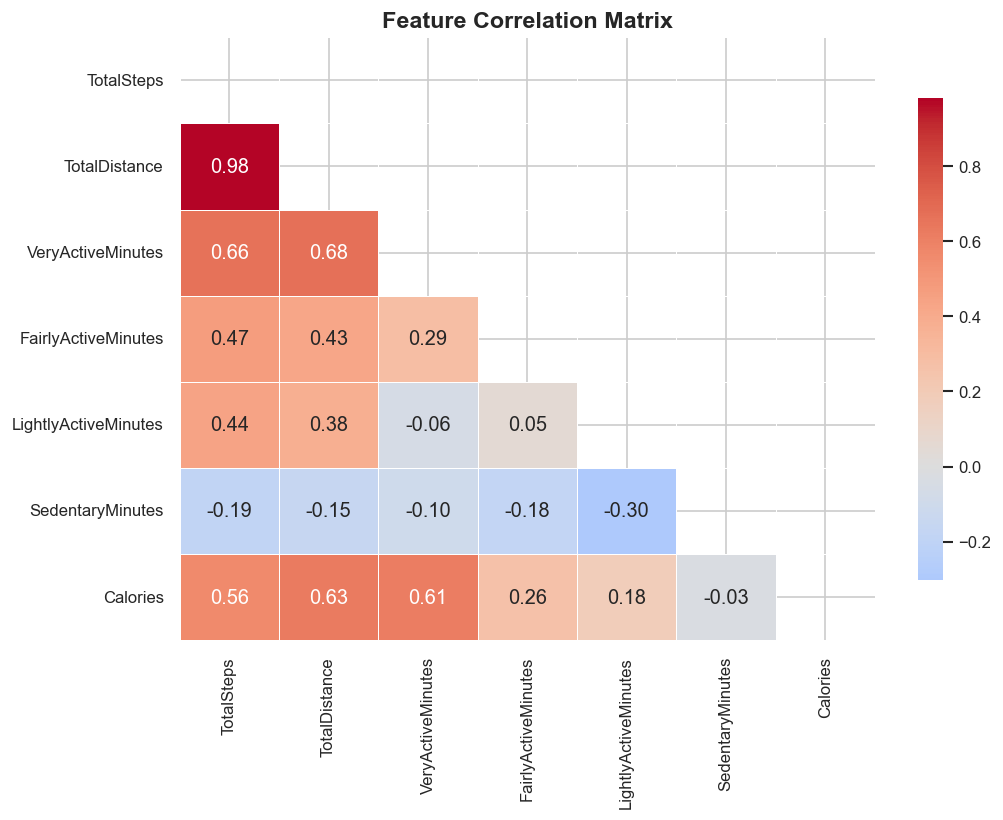

In [19]:
cols = ['TotalSteps', 'TotalDistance', 'VeryActiveMinutes',
        'FairlyActiveMinutes', 'LightlyActiveMinutes',
        'SedentaryMinutes', 'Calories']
corr_matrix = daily_clean[cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

## 12. Key Findings & Recommendations

### 📊 Findings

| # | Finding |
|---|----------|
| 1 | **~66% of users are sedentary or lightly active** — the majority never hit the 10k step goal |
| 2 | **Sedentary time dominates the day** — ~81% of waking hours are spent inactive |
| 3 | **Peak activity window is 12:00–14:00 and 17:00–19:00** — lunchtime and post-work |
| 4 | **Steps and calories are strongly correlated** — step count is a reliable proxy for energy burn |
| 5 | **Many users wear the device inconsistently** — low engagement users are a churn risk |
| 6 | **Most heart rate readings fall in the normal zone** — users are not reaching cardio zones regularly |

### 💡 Bellabeat Marketing Recommendations

1. **Target the sedentary majority** — push gentle movement reminders and "just 5 more minutes" micro-challenges via the app
2. **Leverage the 12:00–19:00 window** — schedule notifications and challenges during peak activity hours
3. **Re-engagement campaign for low-wear users** — send personalized streaks/badges to users who haven't worn the device in 3+ days
4. **Promote heart health features** — highlight heart rate zone tracking for women targeting cardio fitness
5. **Gamify consistency** — weekly step challenges and social sharing to boost retention